In [30]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Descrição do problema
## Parâmetros

In [31]:
# Parâmetros de entrada 
m = 0.073   #(Kg)
g = 9.81    #(m/s^2)
k = 6.51e-5 #(Nm^2/A^2) 
R = 11.0    #(Ohm)

# Condição inicial
x0 = 8.5e-3 #(m)
v0 = 0      #(m/s)

Com esses valores podemos obter o valor de $i_0$ a partir da condição de equilíbrio da REE.

## Representação de Espaço de Estados e Problema do Valor Inicial
Usando a representação por espaço de estados, o sistema anterior deve ser reescrito por meio de equações diferenciais de primeira ordem. Para isso, iremos definir o vetor de variáveis de estado como sendo (i,x,v) e o sistema pode ser reescrito como:

\begin{aligned}
\dot i &= - \frac{R}{L(x)}i - \frac{Bl(i,x)}{L(x)} v + \frac{u}{L(x)}\\
\dot x &= v \\
\dot v &= g - \frac{f_m(i,x)}{m}
\end{aligned}

Em que:
\begin{equation}
L(x) = \frac{k}{x}
\end{equation}
onde $k$ é uma constante obtida experimentalmente. 
\begin{equation}
Bl = \frac{f_m}{i}
\end{equation}
e
\begin{equation}
f_m = \frac{k}{2}\left(\frac{i^2}{x^2}\right)
\end{equation}

In [32]:
# Magnetic force fm
def fm(i,x):
    return k/2*i*i/x/x
# Force Factor
def Bl(i,x):
     return k/2*i/x/x #(N/A)
# Inductance
def L(x):
     return k/x #(H)

# State space representation in vector form
# dy = y´ = function(y,t)
# y = [i,x,v,E]

def f(t,y):
    i,x,v = y
    
    #di/dt
    di = -R/L(x)*i - Bl(i,x)/L(x)*v + u0/L(x)
    #dx/dt
    dx = v
    #dv/dt
    dv = g-fm(i,x)/m
   
    return [di, dx, dv]

Usando a condição de equilíbrio na equação mais simples, encontramos o $i_0$:

\begin{aligned}
0 &= g - \frac{f_m(i_0,x_0)}{m} \\
0 &= g - \frac{k}{2}\left(\frac{i_0^2}{x_0^2}\right)  \frac{1}{m} \\
g &= \frac{k}{2}\left(\frac{i_0^2}{x_0^2}\right)  \frac{1}{m} \\
i_0^2 &= gx_0^2\frac{2m}{k} \\
i_0 &= x_0\sqrt{g\frac{2m}{k}}
\end{aligned}

Substituindo os valores, temos $i_0 = 1.2607 (A)$

Usando a condição de equilíbrio, também conseguimos o valor de $u_0$:

\begin{aligned}
    \dot i &= - \frac{R}{L(x)}i - \frac{Bl(i,x)}{L(x)} v + \frac{u}{L(x)} \\
    \dot iL(x) &= -Ri - Bl(i,x)v + u \\
    0 &= -Ri_0 + 0 + u_0 \\
    u_0 &= -Ri_0
\end{aligned}

In [33]:
i0 = 1.2607 #(A)
u0 = i0*R

## Modelo DELT - UFMG
Modelo usado na disciplina Oficina de Simulação de Sistemas Dinâmicos do Departamento de Engenharia Eletrônica da UFMG. Apenas o modelo mecânico é apresentado, não sendo apresentadas a indutância e a resistência. Reparem também que o modelo é instável mesmo sem adicionarmos um ruído externo, pois a própria aproximação utilizada já faz com que a força resultante seja diferente de zero.

In [34]:
print("\nAt equilibrium:")
print("    i0 = ",i0)
print("    x0 = ",x0)
print("    fm = ",fm(i0,x0))
print("    mg = ",m*g)
print("    fm/fg (%) = ",fm(i0,x0)/(m*g)*100)


At equilibrium:
    i0 =  1.2607
    x0 =  0.0085
    fm =  0.7160389501660898
    mg =  0.71613
    fm/fg (%) =  99.98728585118481


## Operação em malha aberta  

In [35]:
# Initial conditions
# y = [i,x,v]
y_0 = [i0,x0,v0] # y_0 = [i0,x0,v, 0.0]
# Time span
t_0 = 0.0
t_end = 1 #(s) 

sol = solve_ivp(f, [t_0, t_end],y_0)

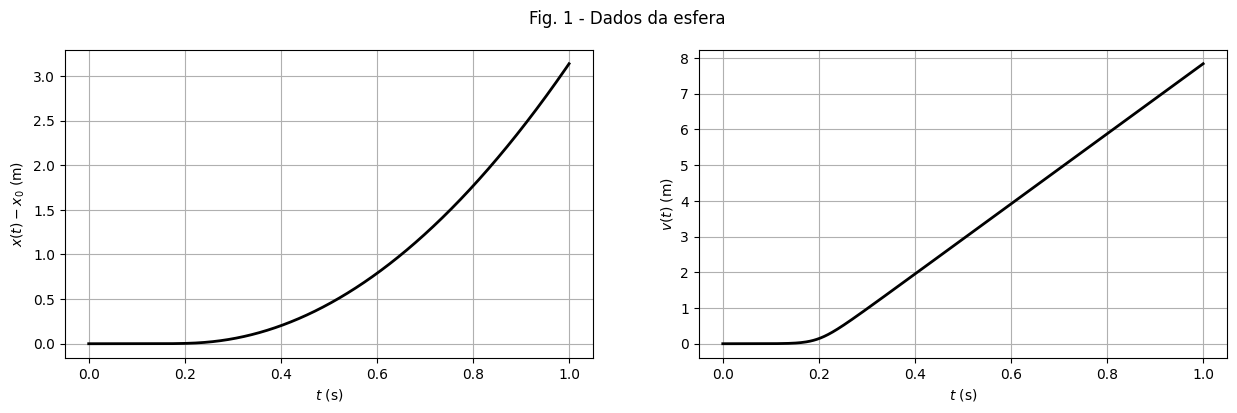

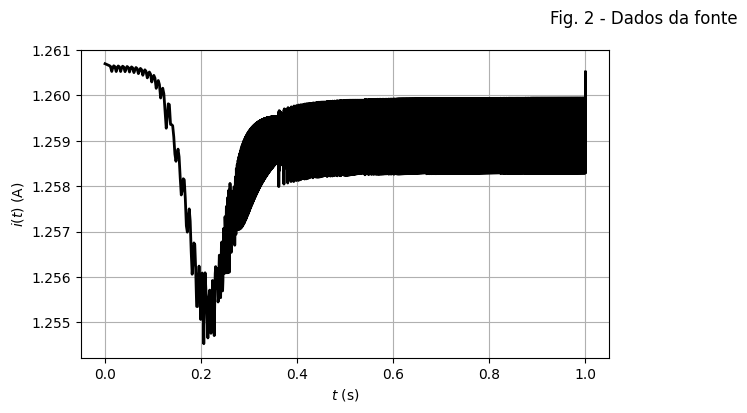

In [36]:
# --- Position plot --- 
fig = plt.figure(figsize=(15,4))
plt.subplot(1, 2, 1)
plt.plot(sol.t, sol.y[1,:]-x0, 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$x(t)-x_0$ (m)');
fig.suptitle('Fig. 1 - Dados da esfera');

plt.subplot(1, 2, 2)
plt.plot(sol.t, sol.y[2,:], 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$v(t)$ (m)');

# --- Source plot ---
fig = plt.figure(figsize=(15,4))
plt.subplot(1, 2, 1)
plt.plot(sol.t, sol.y[0,:], 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$i(t)$ (A)');
fig.suptitle('Fig. 2 - Dados da fonte');

# Atividades do Trabalho Computacional
## Sintonizando o PID
### REE
Para representarmos um sistema com realimentação PID, precisamos alterar a REE que foi apresentada anteriormente.
A entrada realimentada por um PID é dada pela seguinte equação:
\begin{aligned}
u(t) &= u_0 + \Delta u \\
u(t) &= u_0 + K_p e(t) + K_i \int_0^t e(t) + K_d \dot e(t)
\end{aligned}
em que $e(t) = x(t) - x_0$

Como usaremos essa entrada no sistema, precisamos acrescentar um estado na representação de forma que fique no formato adequado. Sendo assim, criaremos o estado $\dot E$:

\begin{equation}
\dot E(t) = e(t)
\end{equation}
O que significa que $E(t) = \int_0^t e(t)$.

Dessa forma, podemos substituí-lo na primeira equação do sistema e teremos a seguinte REE:

\begin{aligned}
\dot i &= - \frac{R}{L(x)}i - \frac{Bl(i,x)}{L(x)} v + \frac{u_0 + K_p e(t) + K_i  E + K_d \dot e(t)}{L(x)}\\
\dot x &= v \\
\dot v &= g - \frac{f_m(i,x)}{m} \\
\dot E &= x - x_0
\end{aligned}

In [37]:
def delta_u(x,E,v):
    return Kp*(x-x0) + Ki*E + Kd*v

def f(t,y):
    i,x,v,E = y
    
    #di/dt
    di = -R/L(x)*i - Bl(i,x)/L(x)*v + u0/L(x) + delta_u(x,E,v)/L(x)
    #dx/dt
    dx = v
    #dv/dt
    dv = g-fm(i,x)/m
    #dE/dt
    dE = x - x0
   
    return [di, dx, dv, dE]

Adicionalmente, como é pedido na atividade, perturbamos a posição inicial do problema com um $\epsilon < 3\%$.

Já os valores de $K_p, K_i$ e $K_d$ são arbitrários e escolhidos na base da tentativa e erro.

In [38]:
# perturbação na posição inicial
epsilon = x0 * 0.03

# parametros do controlador PID
Kp = 10000
Ki = 0
Kd = 1000

Finalmente, podemos verificar se o com a Realimentação do PID o sistema se mantém estável pra uma perturbação pequena na posição inicial.

x inicial =  0.008755
x final =  0.008500105726976123
Erro final =  3.14985045751527e-05
i max =  1.3959483134105506
i min =  1.2569204359818054
u max =  15.355431447516057
u min =  13.82612479579986


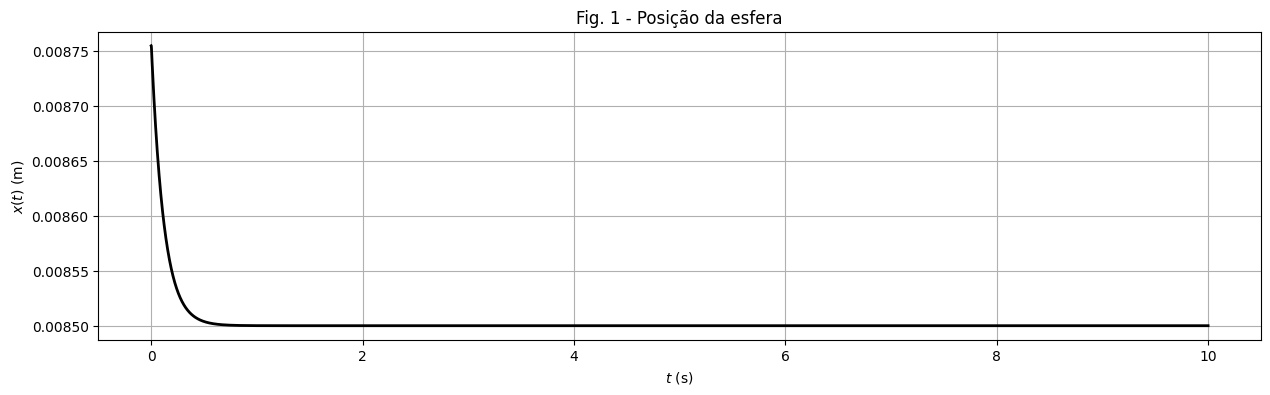

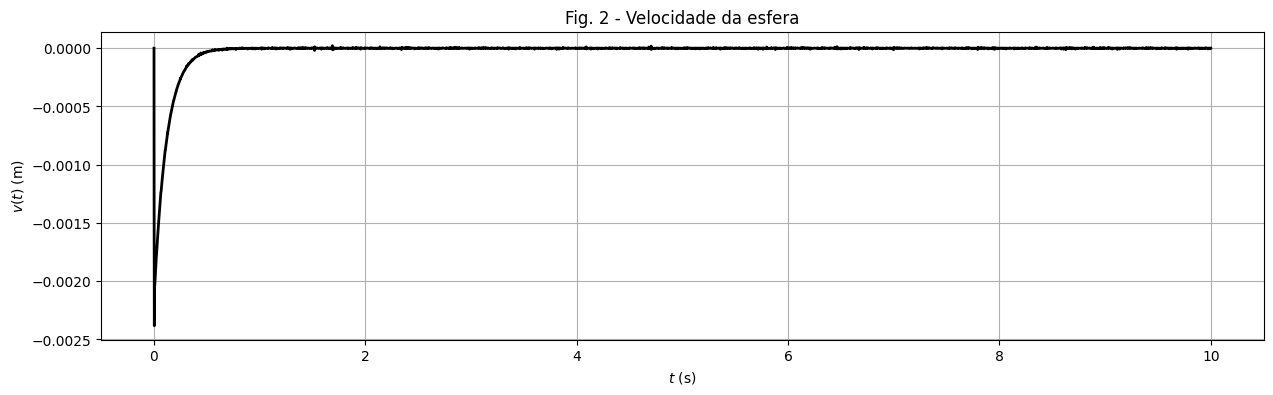

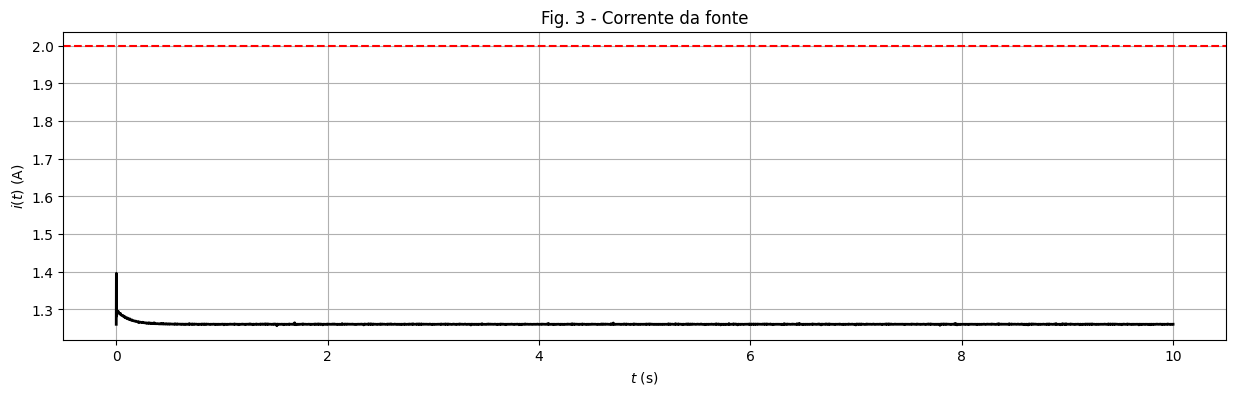

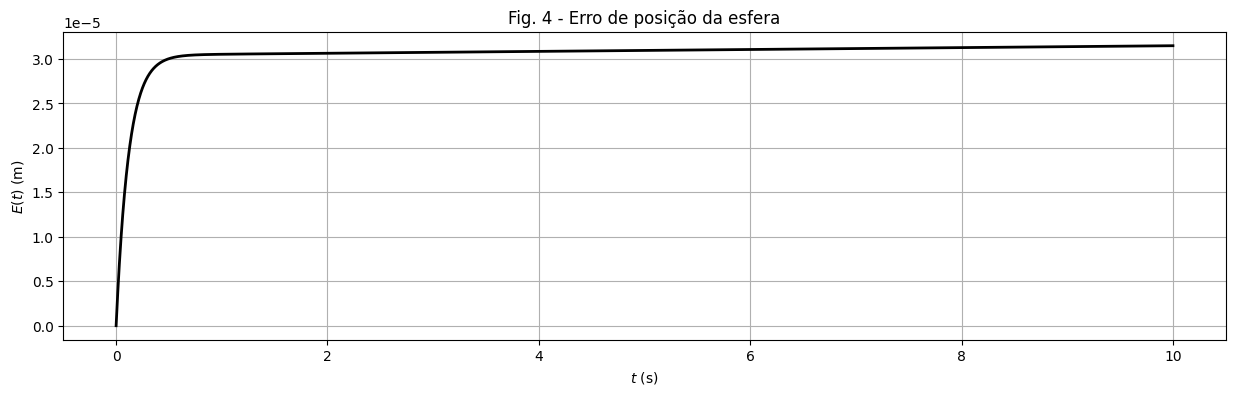

In [39]:
E0 = 0.0

# Initial conditions
# y = [i,x,v,E]
y_0 = [i0,x0+epsilon,v0,E0] 
# Time span
t_0 = 0.0
t_end = 10 #(s) 

sol = solve_ivp(f, [t_0, t_end],y_0)


# --- Position plot --- 
fig = plt.figure(figsize=(15,4))
plt.plot(sol.t, sol.y[1,:], 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$x(t)$ (m)');
plt.title('Fig. 1 - Posição da esfera');

# --- Velocity plot ---
fig = plt.figure(figsize=(15,4))
plt.plot(sol.t, sol.y[2,:], 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$v(t)$ (m)');
plt.title('Fig. 2 - Velocidade da esfera');

# --- Source plot ---
fig = plt.figure(figsize=(15,4))
plt.plot(sol.t, sol.y[0,:], 'k', linewidth=2); 
plt.axhline(2.0, color='r', linestyle='--', linewidth=1.5, label='Limite de 2 A')
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$i(t)$ (A)');
plt.title('Fig. 3 - Corrente da fonte');

# --- Error plot ---
fig = plt.figure(figsize=(15,4))
plt.plot(sol.t, sol.y[3,:], 'k', linewidth=2);
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$E(t)$ (m)');
plt.title('Fig. 4 - Erro de posição da esfera');

print("x inicial = ",y_0[1])
print("x final = ", sol.y[1,-1])
print("Erro final = ", sol.y[3,-1])
print("i max = ", np.max(sol.y[0,:]))
print("i min = ", np.min(sol.y[0,:]))
print("u max = ", np.max(sol.y[0,:])*R)
print("u min = ", np.min(sol.y[0,:])*R)

Agora vamos avaliar a faixa de valores de $\epsilon$ na qual o sistema se mantém estável pra esses valores que foram utilizados no PID.

x inicial =  0.009775
x final =  0.008500106080547236
Erro final =  0.00015323583516876901
i max =  1.9965702053604983
i min =  1.257141764849466
u max =  21.96227225896548
u min =  13.828559413344127


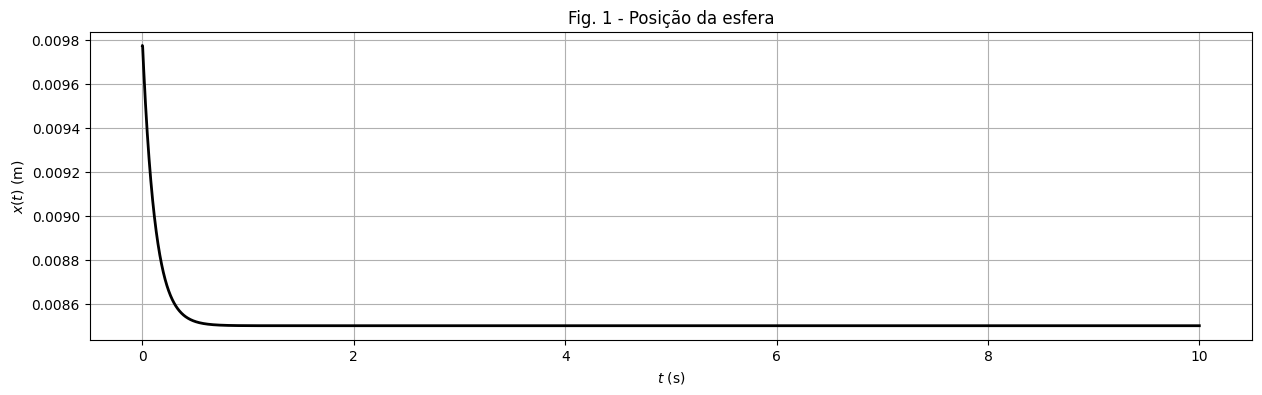

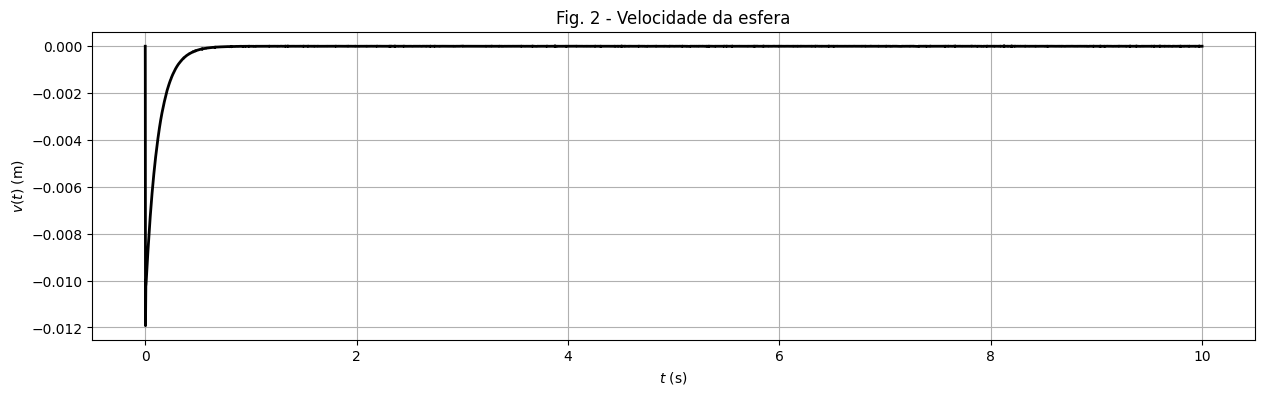

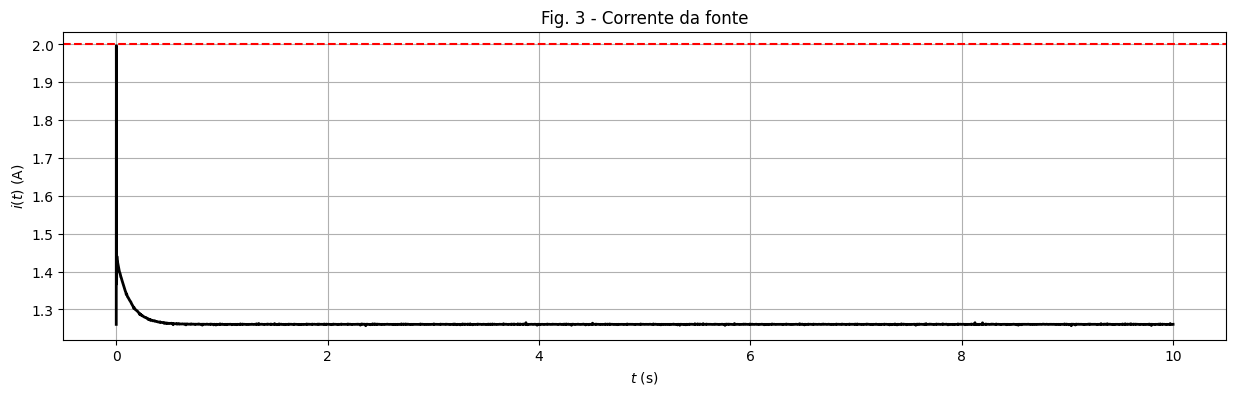

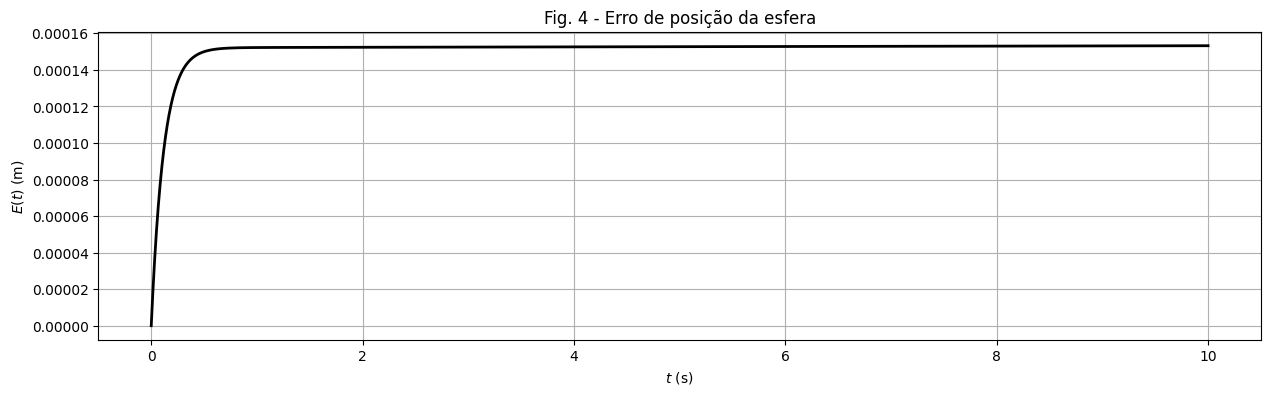

In [40]:
# perturbação na posição inicial positiva
epsilon = x0 * 0.15

# Initial conditions
# y = [i,x,v,E]
y_0 = [i0,x0+epsilon,v0,E0] 
# Time span
t_0 = 0.0
t_end = 10 #(s) 

sol = solve_ivp(f, [t_0, t_end],y_0)

# --- Position plot --- 
fig = plt.figure(figsize=(15,4))
plt.plot(sol.t, sol.y[1,:], 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$x(t)$ (m)');
plt.title('Fig. 1 - Posição da esfera');

# --- Velocity plot ---
fig = plt.figure(figsize=(15,4))
plt.plot(sol.t, sol.y[2,:], 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$v(t)$ (m)');
plt.title('Fig. 2 - Velocidade da esfera');

# --- Source plot ---
fig = plt.figure(figsize=(15,4))
plt.plot(sol.t, sol.y[0,:], 'k', linewidth=2); 
plt.axhline(2.0, color='r', linestyle='--', linewidth=1.5, label='Limite de 2 A')
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$i(t)$ (A)');
plt.title('Fig. 3 - Corrente da fonte');

# --- Error plot ---
fig = plt.figure(figsize=(15,4))
plt.plot(sol.t, sol.y[3,:], 'k', linewidth=2);
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$E(t)$ (m)');
plt.title('Fig. 4 - Erro de posição da esfera');

print("x inicial = ",y_0[1])
print("x final = ", sol.y[1,-1])
print("Erro final = ", sol.y[3,-1])
print("i max = ", np.max(sol.y[0,:]))
print("i min = ", np.min(sol.y[0,:]))
print("u max = ", np.max(sol.y[0,:])*R)
print("u min = ", np.min(sol.y[0,:])*R)

x inicial =  0.0062475000000000004
x final =  0.008500106315946575
Erro final =  -0.0002687547292990049
i max =  1.2650937532042767
i min =  0.013276848982247583
u max =  13.916031285247044
u min =  0.14604533880472342


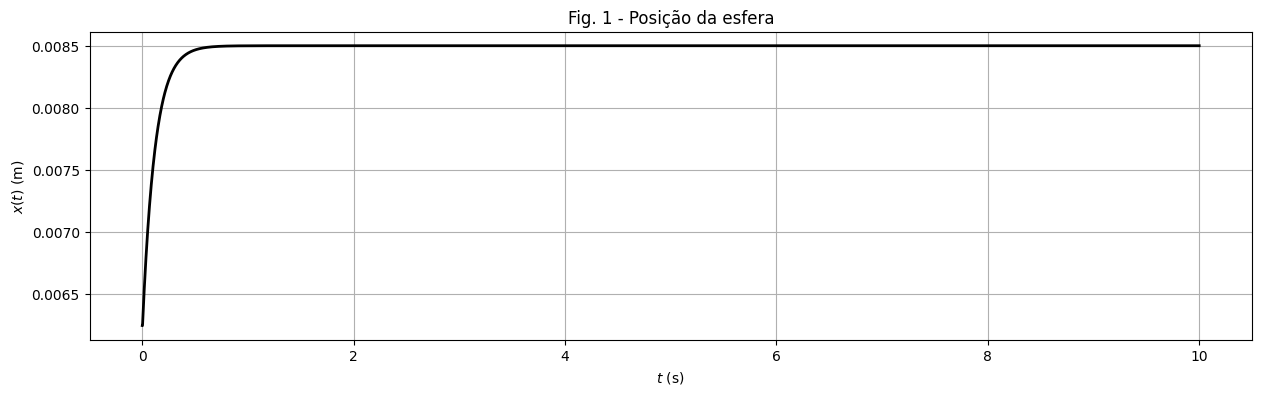

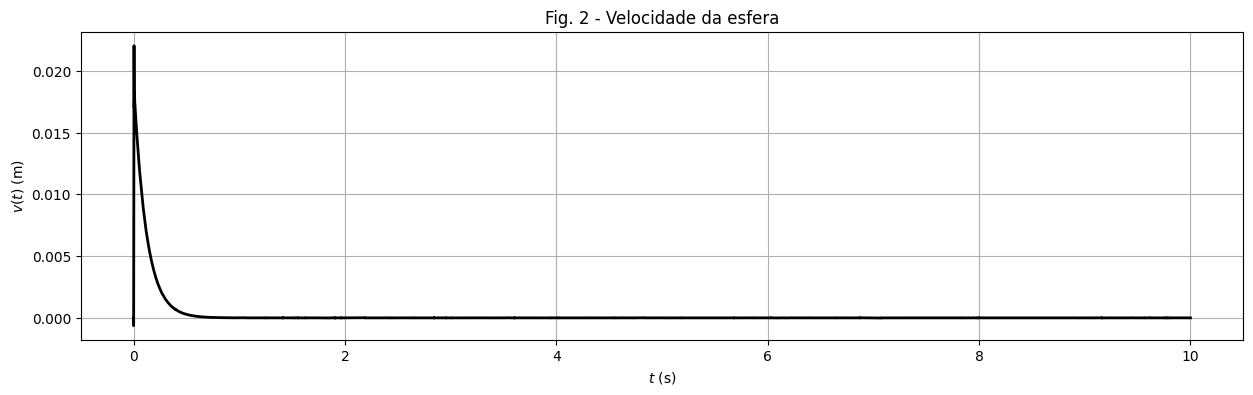

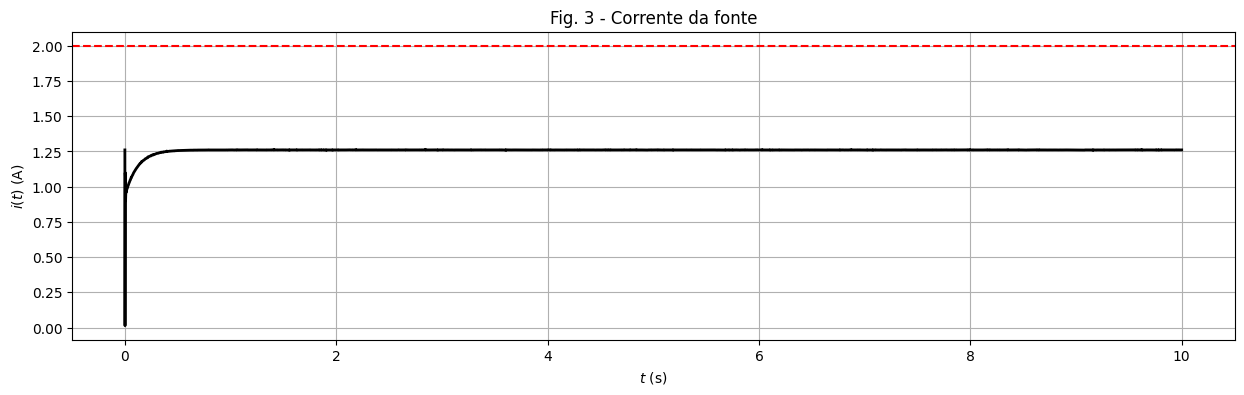

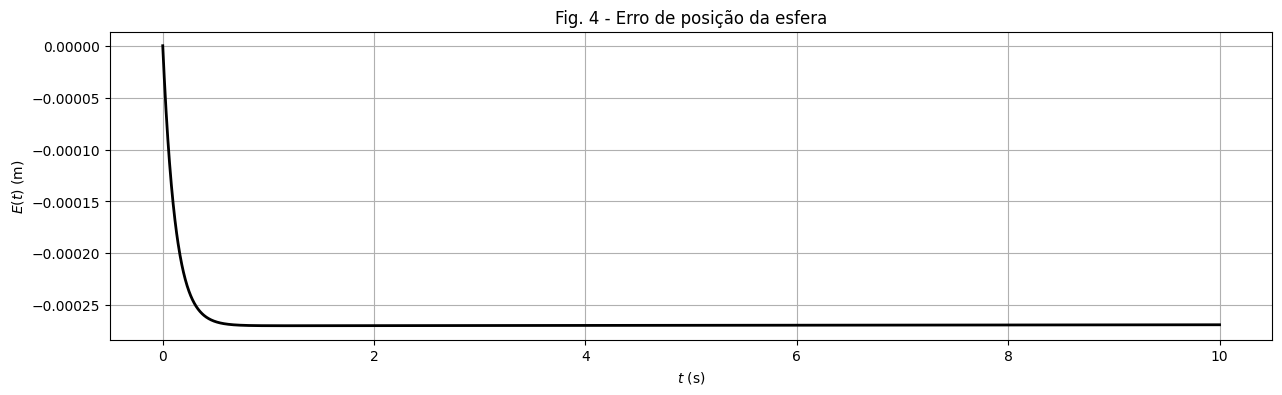

In [41]:
# perturbação na posição inicial negativa
epsilon = x0 * 0.265

# Initial conditions
# y = [i,x,v,E]
y_0 = [i0,x0-epsilon,v0,E0] 
# Time span
t_0 = 0.0
t_end = 10 #(s) 

sol = solve_ivp(f, [t_0, t_end],y_0)

# --- Position plot --- 
fig = plt.figure(figsize=(15,4))
plt.plot(sol.t, sol.y[1,:], 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$x(t)$ (m)');
plt.title('Fig. 1 - Posição da esfera');

# --- Velocity plot ---
fig = plt.figure(figsize=(15,4))
plt.plot(sol.t, sol.y[2,:], 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$v(t)$ (m)');
plt.title('Fig. 2 - Velocidade da esfera');

# --- Source plot ---
fig = plt.figure(figsize=(15,4))
plt.plot(sol.t, sol.y[0,:], 'k', linewidth=2); 
plt.axhline(2.0, color='r', linestyle='--', linewidth=1.5, label='Limite de 2 A')
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$i(t)$ (A)');
plt.title('Fig. 3 - Corrente da fonte');

# --- Error plot ---
fig = plt.figure(figsize=(15,4))
plt.plot(sol.t, sol.y[3,:], 'k', linewidth=2);
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$E(t)$ (m)');
plt.title('Fig. 4 - Erro de posição da esfera');

print("x inicial = ",y_0[1])
print("x final = ", sol.y[1,-1])
print("Erro final = ", sol.y[3,-1])
print("i max = ", np.max(sol.y[0,:]))
print("i min = ", np.min(sol.y[0,:]))
print("u max = ", np.max(sol.y[0,:])*R)
print("u min = ", np.min(sol.y[0,:])*R)

Com os testes feitos na tentativa e erro, conseguimos verificar que a faixa de valores de $\epsilon$ no qual o sistema se mantém estável é $\epsilon=\{-0.265x_0, 0.15x_0\}$. Chegamos nestes valores considerando as limitações de projeto desse levitador magnético, como a corrente máxima da fonte sendo $2A$, e também considerando limitações físicas, como uma fonte de tensão CC não poder gerar correntes negativas, por exemplo.

O valor de $\epsilon=0.15x_0$ chega muito próximo do limite de corrente do levitador e o valor $\epsilon=-0.265x_0$ é um dos ultimos valores no qual a corrente mínima é maior do que $0$.

## Adicionando incerteza à malha de realimentação

Agora vamos adicionar a incerteza na medição do dispositivo que mede a posição da esfera e envia a medição para o PID. Esse ruído tem distribuição normal com:
\begin{equation}
\bar x = 0, \sigma = 0.04x_0
\end{equation}

### Nova REE
Com a adição da incerteza, consequentemente temos a mudança do comportamento do sistema, pois o erro de medição afeta diretamente o controle do PID e, consequentemente, da realimentação. Dessa forma, temos a seguinte REE:
\begin{aligned}
\dot i &= - \frac{R}{L(x)}i - \frac{Bl(i,x)}{L(x)} v + \frac{u_0 + K_p e_m(t) + K_i E_m + K_d \dot e_m(t)}{L(x)}\\
\dot x &= v \\
\dot v &= g - \frac{f_m(i,x)}{m} \\
\dot E_m &= x(t) + n(t) - x_0
\end{aligned}
Sendo 
\begin{aligned}
e_m(t) &= x(t) + n(t) - x_0 \\
n(t) &= \eta (\bar x, \sigma²)
\end{aligned}

In [42]:
sigma = 0.04*x0

def e_m(x):
    n = np.random.normal(0, sigma)
    return x + n - x0

def delta_u(x,E,v):
    n = np.random.normal(0, sigma)
    return Kp*e_m(x) + Ki*E + Kd*v

def f(t,y):
    i,x,v,E = y
    
    #di/dt
    di = -R/L(x)*i - Bl(i,x)/L(x)*v + u0/L(x) + delta_u(x,E,v)/L(x)
    #dx/dt
    dx = v
    #dv/dt
    dv = g-fm(i,x)/m
    #dE/dt
    dE = e_m(x)
   
    return [di, dx, dv, dE]

Podemos ver que para o valor  anteriormente dado de $\epsilon < 3\%$ o sistema se mantém estável.

x inicial =  0.008755
x final =  0.008494311791887433
Erro final =  5.3681711779264235e-05
i max =  1.4844742894337182
i min =  1.053792915511394
u max =  16.3292171837709
u min =  11.591722070625336


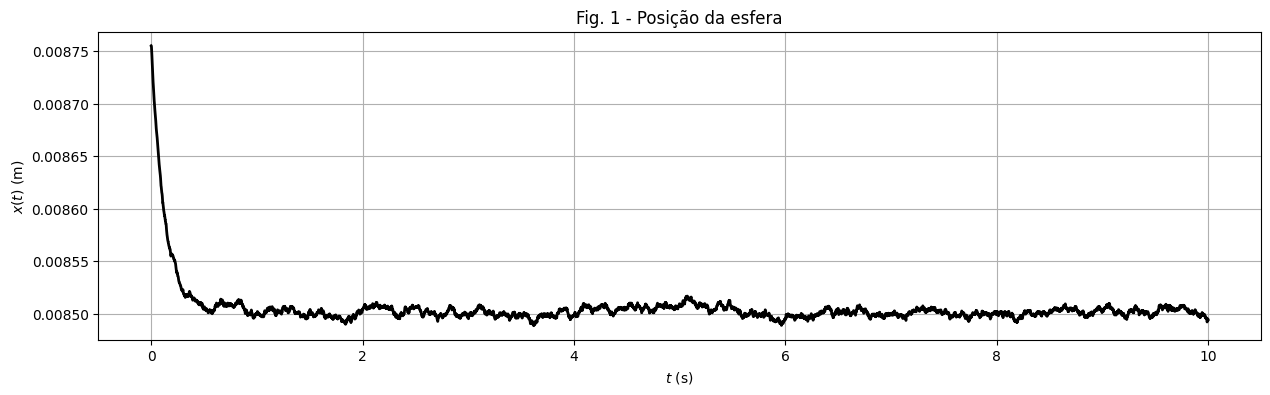

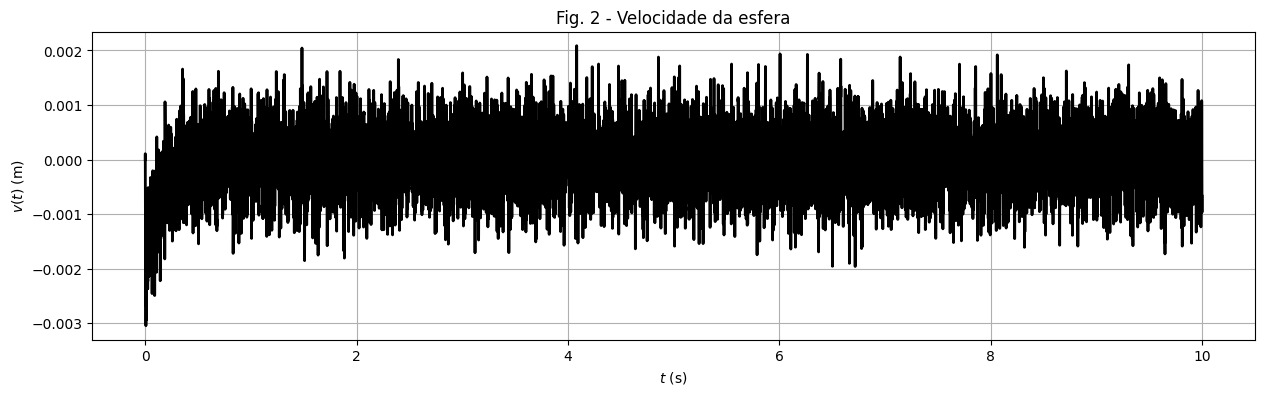

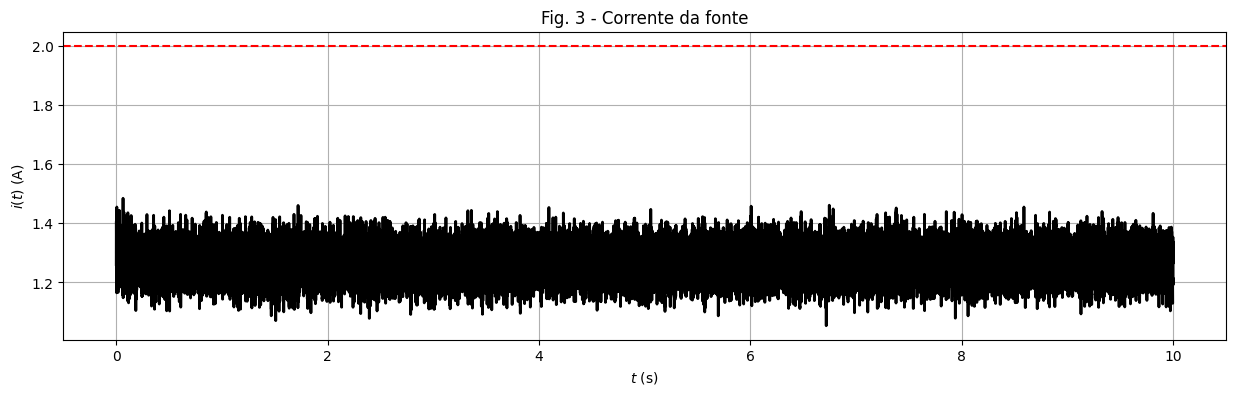

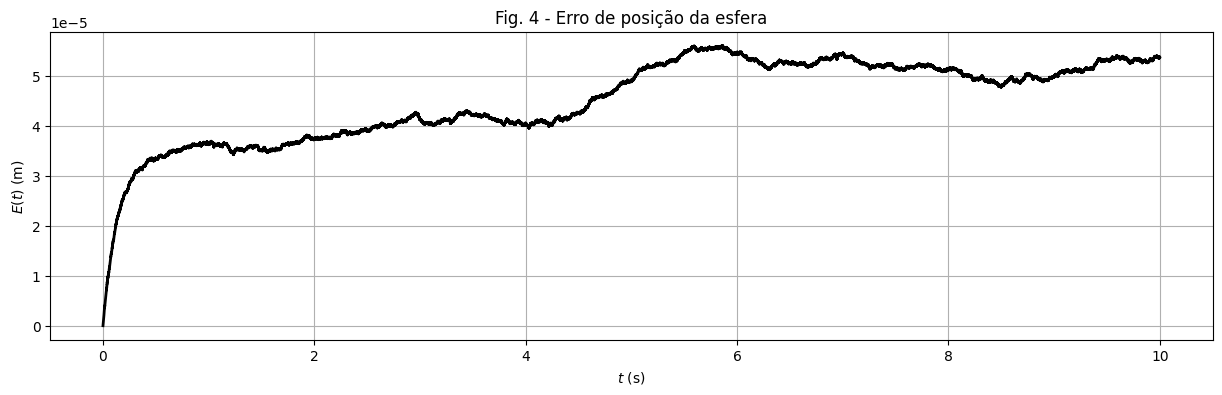

In [44]:
# perturbação na posição inicial
epsilon = x0 * 0.03

# Initial conditions
# y = [i,x,v,E]
y_0 = [i0,x0+epsilon,v0,E0] 
# Time span
t_0 = 0.0
t_end = 10 #(s) 

sol = solve_ivp(f, [t_0, t_end],y_0)


# --- Position plot --- 
fig = plt.figure(figsize=(15,4))
plt.plot(sol.t, sol.y[1,:], 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$x(t)$ (m)');
plt.title('Fig. 1 - Posição da esfera');

# --- Velocity plot ---
fig = plt.figure(figsize=(15,4))
plt.plot(sol.t, sol.y[2,:], 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$v(t)$ (m)');
plt.title('Fig. 2 - Velocidade da esfera');

# --- Source plot ---
fig = plt.figure(figsize=(15,4))
plt.plot(sol.t, sol.y[0,:], 'k', linewidth=2); 
plt.axhline(2.0, color='r', linestyle='--', linewidth=1.5, label='Limite de 2 A')
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$i(t)$ (A)');
plt.title('Fig. 3 - Corrente da fonte');

# --- Error plot ---
fig = plt.figure(figsize=(15,4))
plt.plot(sol.t, sol.y[3,:], 'k', linewidth=2);
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$E(t)$ (m)');
plt.title('Fig. 4 - Erro de posição da esfera');

print("x inicial = ",y_0[1])
print("x final = ", sol.y[1,-1])
print("Erro final = ", sol.y[3,-1])
print("i max = ", np.max(sol.y[0,:]))
print("i min = ", np.min(sol.y[0,:]))
print("u max = ", np.max(sol.y[0,:])*R)
print("u min = ", np.min(sol.y[0,:])*R)

Agora vamos reavaliar a faixa de valores que $\epsilon$ pode assumir enquanto o sistema se mantém estável, novamente, respeitando as limitações físicas e de projeto.

x inicial =  0.00969
x final =  0.008495216726037503
Erro final =  0.00014849945612062666
i max =  1.9633420357318243
i min =  1.0409423955416237
u max =  21.596762393050067
u min =  11.45036635095786


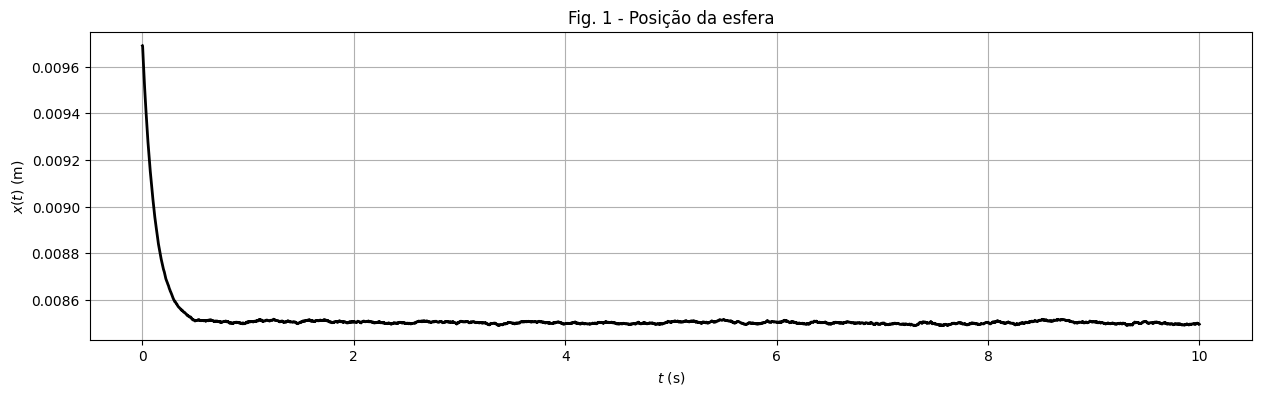

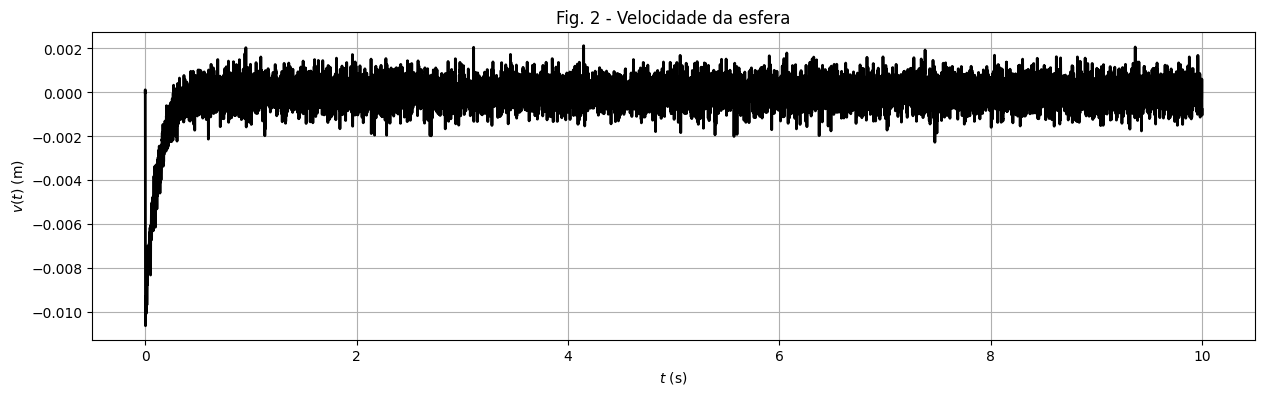

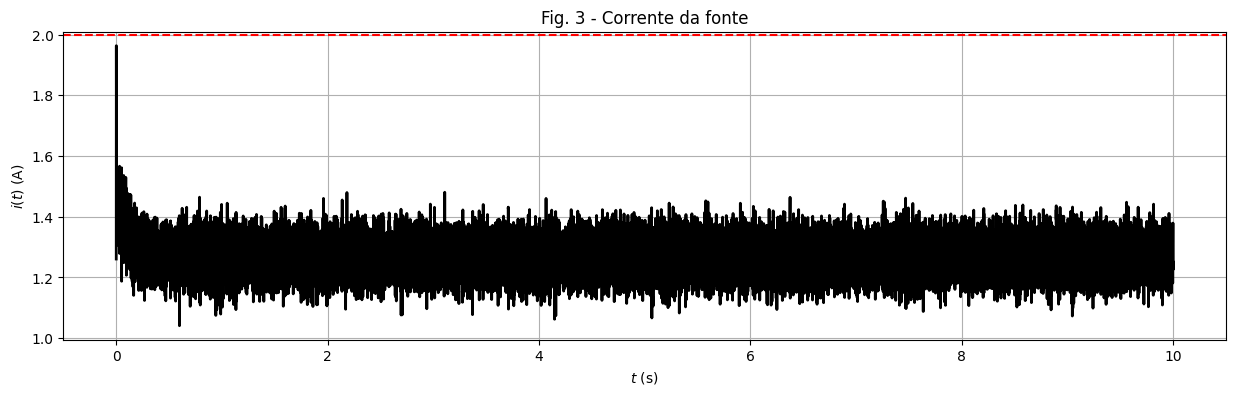

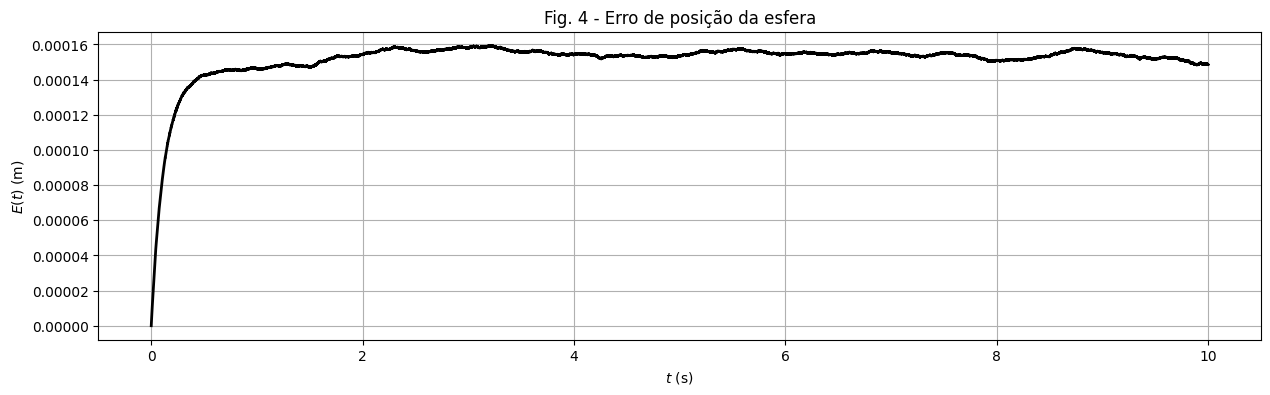

In [52]:
# perturbação na posição inicial
epsilon = x0 * 0.14

# Initial conditions
# y = [i,x,v,E]
y_0 = [i0,x0+epsilon,v0,E0] 
# Time span
t_0 = 0.0
t_end = 10 #(s) 

sol = solve_ivp(f, [t_0, t_end],y_0)


# --- Position plot --- 
fig = plt.figure(figsize=(15,4))
plt.plot(sol.t, sol.y[1,:], 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$x(t)$ (m)');
plt.title('Fig. 1 - Posição da esfera');

# --- Velocity plot ---
fig = plt.figure(figsize=(15,4))
plt.plot(sol.t, sol.y[2,:], 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$v(t)$ (m)');
plt.title('Fig. 2 - Velocidade da esfera');

# --- Source plot ---
fig = plt.figure(figsize=(15,4))
plt.plot(sol.t, sol.y[0,:], 'k', linewidth=2); 
plt.axhline(2.0, color='r', linestyle='--', linewidth=1.5, label='Limite de 2 A')
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$i(t)$ (A)');
plt.title('Fig. 3 - Corrente da fonte');

# --- Error plot ---
fig = plt.figure(figsize=(15,4))
plt.plot(sol.t, sol.y[3,:], 'k', linewidth=2);
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$E(t)$ (m)');
plt.title('Fig. 4 - Erro de posição da esfera');

print("x inicial = ",y_0[1])
print("x final = ", sol.y[1,-1])
print("Erro final = ", sol.y[3,-1])
print("i max = ", np.max(sol.y[0,:]))
print("i min = ", np.min(sol.y[0,:]))
print("u max = ", np.max(sol.y[0,:])*R)
print("u min = ", np.min(sol.y[0,:])*R)

x inicial =  0.0062900000000000005
x final =  0.008503413496980248
Erro final =  -0.00024007890709061856
i max =  1.4758076242636284
i min =  0.021459959613972908
u max =  16.233883866899912
u min =  0.236059555753702


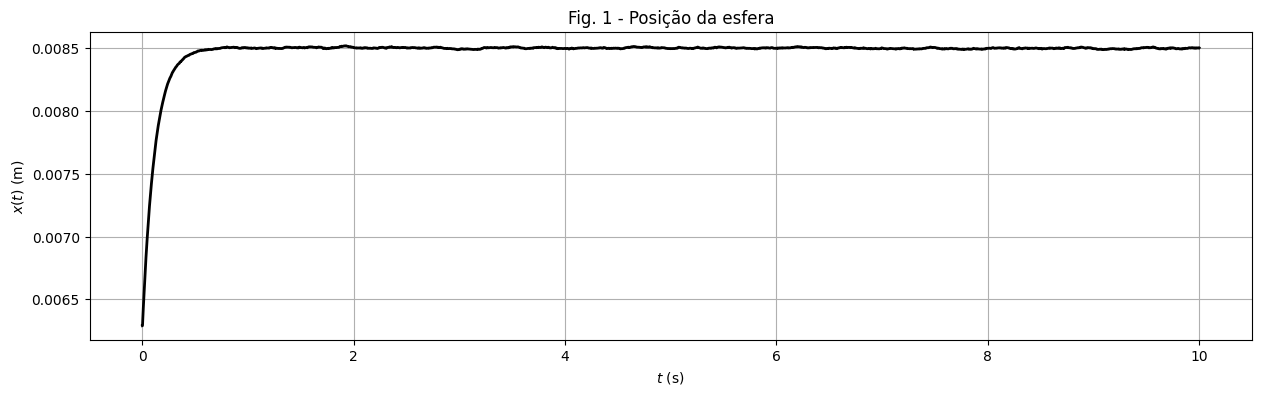

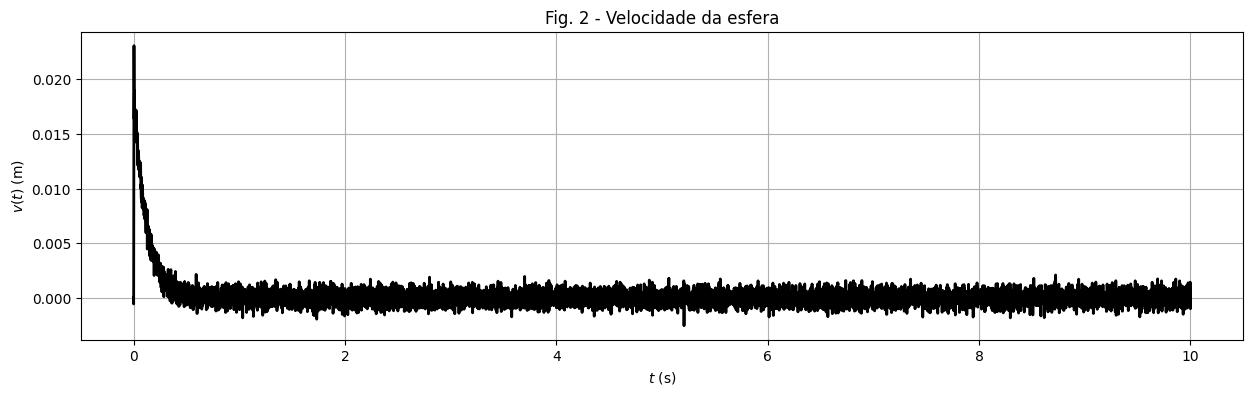

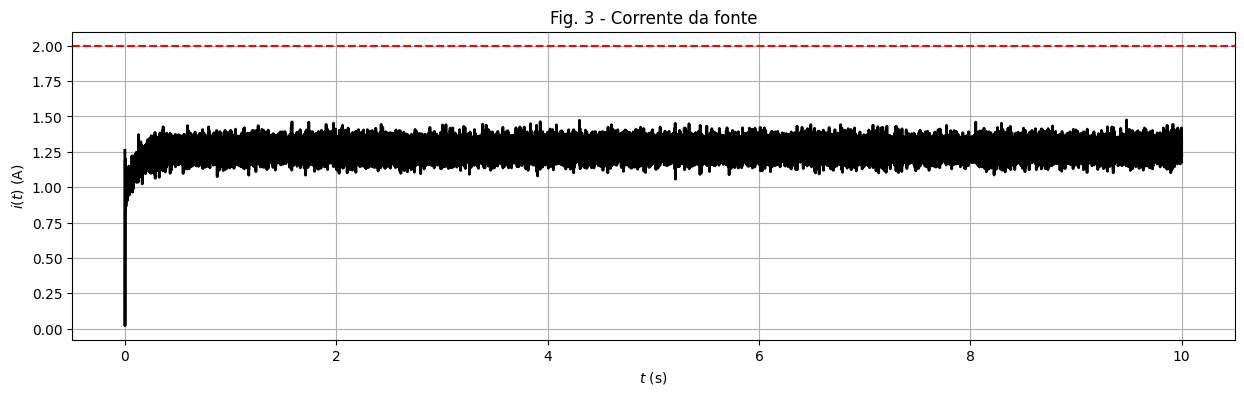

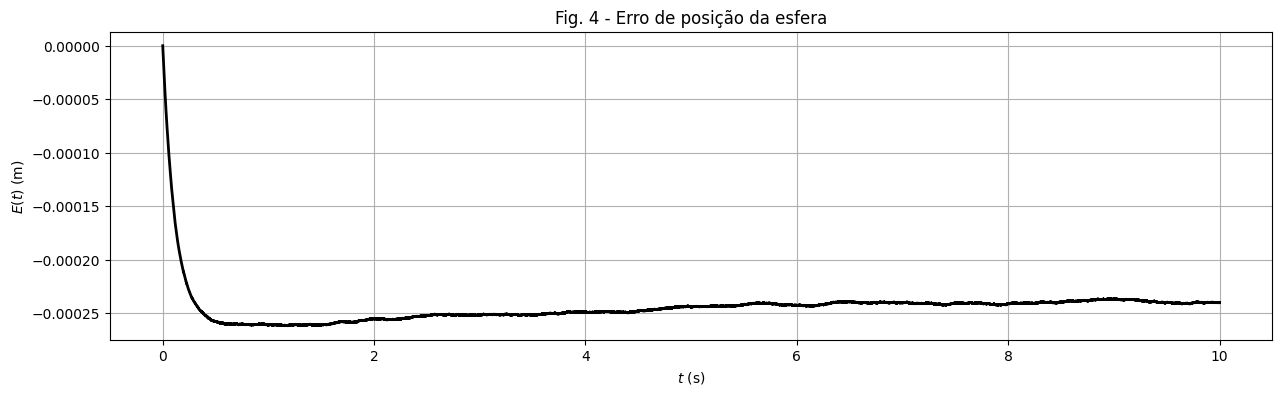

In [50]:
# perturbação na posição inicial
epsilon = x0 * 0.26

# Initial conditions
# y = [i,x,v,E]
y_0 = [i0,x0-epsilon,v0,E0] 
# Time span
t_0 = 0.0
t_end = 10 #(s) 

sol = solve_ivp(f, [t_0, t_end],y_0)


# --- Position plot --- 
fig = plt.figure(figsize=(15,4))
plt.plot(sol.t, sol.y[1,:], 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$x(t)$ (m)');
plt.title('Fig. 1 - Posição da esfera');

# --- Velocity plot ---
fig = plt.figure(figsize=(15,4))
plt.plot(sol.t, sol.y[2,:], 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$v(t)$ (m)');
plt.title('Fig. 2 - Velocidade da esfera');

# --- Source plot ---
fig = plt.figure(figsize=(15,4))
plt.plot(sol.t, sol.y[0,:], 'k', linewidth=2); 
plt.axhline(2.0, color='r', linestyle='--', linewidth=1.5, label='Limite de 2 A')
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$i(t)$ (A)');
plt.title('Fig. 3 - Corrente da fonte');

# --- Error plot ---
fig = plt.figure(figsize=(15,4))
plt.plot(sol.t, sol.y[3,:], 'k', linewidth=2);
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$E(t)$ (m)');
plt.title('Fig. 4 - Erro de posição da esfera');

print("x inicial = ",y_0[1])
print("x final = ", sol.y[1,-1])
print("Erro final = ", sol.y[3,-1])
print("i max = ", np.max(sol.y[0,:]))
print("i min = ", np.min(sol.y[0,:]))
print("u max = ", np.max(sol.y[0,:])*R)
print("u min = ", np.min(sol.y[0,:])*R)